In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os

path = "/content/drive/MyDrive"

for item in os.listdir(path):
    print(item)

IMG_20231218_112710_148.pdf
‏مستند من Mohamed
Classroom
نسخة من ch2.pdf
Colab Notebooks
supermarket.csv
test.zip
archive (3).zip
archive (4).zip
archive (5).zip
archive (7).zip
archive (4)
archive (5)


In [ ]:
import zipfile
import os

zip_files = [
    "/content/drive/MyDrive/archive (4).zip",
    "/content/drive/MyDrive/archive (5).zip",
    "/content/drive/MyDrive/archive (7).zip"
]

for zip_path in zip_files:
    extract_path = zip_path.replace(".zip", "")

    if os.path.exists(extract_path):
        print(f"Already extracted: {extract_path}")
        continue

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"تم فك الضغط: {zip_path}")

Already extracted: /content/drive/MyDrive/archive (4)
Already extracted: /content/drive/MyDrive/archive (5)
Already extracted: /content/drive/MyDrive/archive (7)


In [ ]:
yawdd_cwe_train_path = "/content/drive/MyDrive/archive (4)/yawdd,cwe,glasses-dataset/train"
DDD_imgs_path = "/content/drive/MyDrive/archive (7)/imgs"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/archive (4)/yawdd,cwe,glasses-dataset"))
print(os.listdir("/content/drive/MyDrive/archive (7)/imgs"))

['train']
['test', 'train']


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

def load_images_labels(path, label_map, size=(224,224)):
    """
    path: مسار المجلد الرئيسي للـ dataset
    label_map: dictionary لتحويل أسماء الفئات لرقم واحد (مثلاً Normal=0)
    size: حجم الصورة بعد الـ resize
    """
    images = []
    labels = []

    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue

        label = label_map.get(folder, None)
        if label is None:
            continue

        for img_file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, size)
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [ ]:
yawdd_path = "/content/drive/MyDrive/archive (4)/yawdd"
cwe_path = "/content/drive/MyDrive/archive (4)/cwe"
DDD_path = "/content/drive/MyDrive/archive (5)/Driver Drowsiness Dataset (DDD)"

In [ ]:

import os

path = "/content/drive/MyDrive/archive (4)"
print("المجلدات الموجودة في archive (4):")
print(os.listdir(path))

المجلدات الموجودة في archive (4):
['yawdd,cwe,glasses-dataset']


In [ ]:
yawdd_cwe_train_path = "/content/drive/MyDrive/archive (4)/yawdd,cwe,glasses-dataset/train"

import os
print(os.listdir(yawdd_cwe_train_path))

['Closed', 'Open', 'no_yawn', 'yawn']


In [ ]:

yawdd_cwe_train_path = "/content/drive/MyDrive/archive (4)/yawdd,cwe,glasses-dataset/train"


DDD_imgs_path = "/content/drive/MyDrive/archive (7)/imgs"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"

In [ ]:
def load_images_labels(path, label_map, size=(224,224)):
    images = []
    labels = []
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue
        label = label_map.get(folder, None)
        if label is None:
            continue
        for img_file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, size)
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

In [ ]:
def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    images = []
    labels = []
    df = pd.read_csv(csv_path)
    for idx, row in df.iterrows():
        img_file = row['filename']
        class_name = row['classname']
        label = label_map.get(class_name, None)
        if label is None:
            continue
        img = cv2.imread(os.path.join(img_path, img_file))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

In [ ]:
label_map = {
    "Open": 0,
    "no_yawn": 0,

    "Closed": 1,
    "yawn": 1,


    "c0": 0,

    "c1": 2,
    "c2": 2,
    "c3": 2,
    "c4": 2,
    "c5": 2,
    "c6": 2,

    "c7": 1,
    "c8": 1,
    "c9": 1
}

In [ ]:
import pandas as pd

DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"
df = pd.read_csv(DDD_csv_path)

print(df.head())
print(df.columns)

  subject classname            img
0    p012        c0  img_10206.jpg
1    p012        c0  img_27079.jpg
2    p012        c0  img_50749.jpg
3    p012        c0  img_97089.jpg
4    p012        c0  img_37741.jpg
Index(['subject', 'classname', 'img'], dtype='object')


In [ ]:
def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    images = []
    labels = []
    df = pd.read_csv(csv_path)
    for idx, row in df.iterrows():
        img_file = row['img']
        class_name = row['classname']
        label = label_map.get(class_name, None)
        if label is None:
            continue
        img = cv2.imread(os.path.join(img_path, img_file))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

In [ ]:

X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_path, DDD_csv_path, label_map)

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

DDD_imgs_path = "/content/drive/MyDrive/archive (7)/imgs"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {
    'c0': 0,
    'c1': 1,
    'c2': 2
}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []
    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue
        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue
        img = cv2.imread(img_full_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)


X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_path, DDD_csv_path, label_map_DDD)

print("DDD images:", X_DDD.shape)
print("DDD labels:", y_DDD.shape)

DDD images: (0,)
DDD labels: (0,)


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

DDD_imgs_path = "/content/drive/MyDrive/archive (7)/imgs"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {
    'c0': 0,
    'c1': 1,
    'c2': 2
}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []
    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue
        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue
        img = cv2.imread(img_full_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)


X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_path, DDD_csv_path, label_map_DDD)

print("DDD images:", X_DDD.shape)
print("DDD labels:", y_DDD.shape)

DDD images: (0,)
DDD labels: (0,)


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os


DDD_imgs_path = "/content/drive/MyDrive/archive (7)/imgs"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {
    'c0': 0,
    'c1': 1,
    'c2': 2
}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []
    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue
        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue
        img = cv2.imread(img_full_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)


X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_path, DDD_csv_path, label_map_DDD)

print("DDD images shape:", X_DDD.shape)
print("DDD labels shape:", y_DDD.shape)

DDD images shape: (0,)
DDD labels shape: (0,)


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

DDD_imgs_path = "/content/drive/MyDrive/archive (7)/imgs"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {'c0': 0, 'c1': 1, 'c2': 2}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []
    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue
        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue
        img = cv2.imread(img_full_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y


X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_path, DDD_csv_path, label_map_DDD)

print("DDD images shape:", X_DDD.shape)
print("DDD labels shape:", y_DDD.shape)

DDD images shape: (0,)
DDD labels shape: (0,)


In [ ]:
import os


print(os.listdir("/content/drive/MyDrive/archive (7)/imgs")[:10])

['test', 'train']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/archive (7)/driver_imgs_list.csv")
print(df['img'].head(10))

0    img_10206.jpg
1    img_27079.jpg
2    img_50749.jpg
3    img_97089.jpg
4    img_37741.jpg
5    img_65697.jpg
6     img_3866.jpg
7    img_19098.jpg
8    img_31885.jpg
9    img_41423.jpg
Name: img, dtype: object


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

DDD_imgs_train_path = "/content/drive/MyDrive/archive (7)/imgs/train"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {'c0': 0, 'c1': 1, 'c2': 2}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []

    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue

        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue

        img = cv2.imread(img_full_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y

X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_train_path, DDD_csv_path, label_map_DDD)

print("DDD images shape:", X_DDD.shape)
print("DDD labels shape:", y_DDD.shape)

DDD images shape: (0,)
DDD labels shape: (0,)


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

DDD_imgs_train_path = "/content/drive/MyDrive/archive (7)/imgs/train"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {
    "c0": 0,
    "c1": 1,
    "c2": 2
}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []

    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue

        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue

        img = cv2.imread(img_full_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y


X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_train_path, DDD_csv_path, label_map_DDD)

print("DDD images shape:", X_DDD.shape)
print("DDD labels shape:", y_DDD.shape)

DDD images shape: (0,)
DDD labels shape: (0,)


In [ ]:
import os


print(os.listdir("/content/drive/MyDrive/archive (7)/imgs")[:20])

['test', 'train']


In [ ]:
DDD_imgs_train_path = "/content/drive/MyDrive/archive (7)/imgs/train"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"

In [ ]:
def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    import cv2
    import numpy as np
    import pandas as pd
    import os

    df = pd.read_csv(csv_path)
    images = []
    labels = []

    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue

        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue

        img = cv2.imread(img_full_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

DDD_imgs_train_path = "/content/drive/MyDrive/archive (7)/imgs/train"
DDD_csv_path = "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv"


label_map_DDD = {
    "c0": 0,
    "c1": 1,
    "c2": 2
}

def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    df = pd.read_csv(csv_path)
    images = []
    labels = []

    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue

        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue

        img = cv2.imread(img_full_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y

# تحميل الصور
X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_train_path, DDD_csv_path, label_map_DDD)

print("DDD images shape:", X_DDD.shape)
print("DDD labels shape:", y_DDD.shape)

DDD images shape: (0,)
DDD labels shape: (0,)


In [ ]:
X_DDD, y_DDD = load_DDD_images_labels(DDD_imgs_train_path, DDD_csv_path, label_map_DDD)
print("DDD images shape:", X_DDD.shape)
print("DDD labels shape:", y_DDD.shape)

DDD images shape: (0,)
DDD labels shape: (0,)


In [ ]:
X = X_yawdd
y = y_yawdd

# تطبيع
X = X.astype('float32') / 255.0

# تقسيم البيانات
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# تحويل ل One-hot
y_train = to_categorical(y_train, num_classes=3)
y_val = to_categorical(y_val, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1939, 224, 224, 3) (1939, 3)
Validation: (416, 224, 224, 3) (416, 3)
Test: (416, 224, 224, 3) (416, 3)


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/archive (7)/driver_imgs_list.csv")
print(df.head())

  subject classname            img
0    p012        c0  img_10206.jpg
1    p012        c0  img_27079.jpg
2    p012        c0  img_50749.jpg
3    p012        c0  img_97089.jpg
4    p012        c0  img_37741.jpg


In [ ]:
def load_DDD_images_labels(img_path, csv_path, label_map, size=(224,224)):
    import cv2, os, numpy as np
    df = pd.read_csv(csv_path)
    images = []
    labels = []

    for _, row in df.iterrows():
        img_file = row['img']
        classname = row['classname']
        label = label_map.get(classname, None)
        if label is None:
            continue
        img_full_path = os.path.join(img_path, img_file)
        if not os.path.exists(img_full_path):
            continue
        img = cv2.imread(img_full_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
        labels.append(label)

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

In [ ]:
X_DDD, y_DDD = load_DDD_images_labels("/content/drive/MyDrive/archive (7)/imgs/train",
                                      "/content/drive/MyDrive/archive (7)/driver_imgs_list.csv",
                                      label_map_DDD)

if X_DDD.size > 0:
    X = np.concatenate([X_yawdd, X_DDD], axis=0)
    y = np.concatenate([y_yawdd, y_DDD], axis=0)
else:
    X = X_yawdd
    y = y_yawdd

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 حالات: Normal, Drowsy, Distracted
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.6380 - loss: 0.6677 - val_accuracy: 0.6490 - val_loss: 0.5680
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.7746 - loss: 0.4544 - val_accuracy: 0.7067 - val_loss: 0.4337
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.8314 - loss: 0.3556 - val_accuracy: 0.8606 - val_loss: 0.3435
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.8556 - loss: 0.3310 - val_accuracy: 0.7861 - val_loss: 0.3884
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.8742 - loss: 0.2894 - val_accuracy: 0.8678 - val_loss: 0.3098
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step - accuracy: 0.9087 - loss: 0.2227 - val_accuracy: 0.8822 - val_loss: 0.3083
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.9190 - loss: 0.1935 - val_accuracy: 0.8822 - val_loss: 0.2724
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.9257 - loss: 0.1885 - val_accuracy: 0.9038 - v

In [ ]:
# بعد التدريب مباشرة
model.save("/content/driver_state_cnn_model.h5")

# وتحميله بعد كده
from tensorflow.keras.models import load_model
model = load_model("/content/driver_state_cnn_model.h5")

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9351 - loss: 0.2859
Test accuracy: 0.9350961446762085


In [ ]:
model.save("driver_state_cnn_model.h5")

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       208
           1       0.95      0.92      0.93       208

    accuracy                           0.94       416
   macro avg       0.94      0.94      0.94       416
weighted avg       0.94      0.94      0.94       416



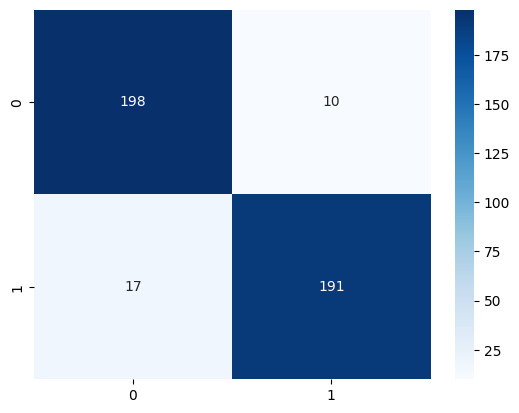

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [ ]:

model.save("/content/driver_state_cnn_model.h5")

In [ ]:
model.save("/content/drive/MyDrive/my_model.h5")

In [ ]:
with open("/content/drive/MyDrive/history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# INSTALL DEPENDENCIES
# =========================
!pip install streamlit opencv-python-headless --quiet
!apt-get install -y ffmpeg --quiet
!npm install -g localtunnel --quiet

import os
import threading
import time

# =========================
# STREAMLIT APP CODE
# =========================
streamlit_code = r"""
import streamlit as st
import cv2
import numpy as np
import tempfile
import os
import time
import base64

st.set_page_config(page_title="AI Driver Monitor", layout="wide")

st.markdown('''
<style>
.stApp { background-color: #0b0e14; color: #e0e0e0; }
.metric-card { background-color: #161b22; padding: 15px; border-radius: 10px; border: 1px solid #30363d; margin-bottom: 10px; }
.status-led { padding: 14px; border-radius: 8px; text-align: center; font-weight: bold; margin: 8px 0; border: 1px solid #30363d; font-size: 18px; }
</style>
''', unsafe_allow_html=True)

st.markdown("<h1 style='text-align:center;'>🛡️ Driver State Detection</h1>", unsafe_allow_html=True)
st.divider()

col1, col2, col3 = st.columns([1.1, 3.5, 1.2])

with col1:
    st.subheader("🛠 AI Status")
    st.markdown("<div class='metric-card'>🔊 Audio Alert: Active</div>", unsafe_allow_html=True)
    st.markdown("<div class='metric-card'>🚗 Slowdown: Standby</div>", unsafe_allow_html=True)
    st.markdown("<div class='metric-card'>⚠️ Hazard: Armed</div>", unsafe_allow_html=True)

with col2:
    st.subheader("📽 Video Feed")
    video_file = st.file_uploader("ارفع فيديو للتحليل", type=['mp4', 'mov', 'avi'])
    video_placeholder = st.empty()
    status_text = st.empty()
    progress_bar = st.progress(0)

with col3:
    st.subheader("📊 Detection States")
    normal_ui = st.empty()
    drowsy_ui = st.empty()
    distract_ui = st.empty()
    log_placeholder = st.empty()

if video_file:
    tfile = tempfile.NamedTemporaryFile(delete=False, suffix='.mp4')
    tfile.write(video_file.read())
    tfile.close()

    st.success("✅ الفيديو تم تحميله")

    if st.button("🚀 ابدأ معالجة الفيديو", type="primary"):
        with st.spinner("جاري معالجة الفيديو..."):
            cap = cv2.VideoCapture(tfile.name)
            output_path = "processed_video.mp4"
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25
            w, h = 640, 360

            out = cv2.VideoWriter(output_path, fourcc, fps, (w*2, h))

            frame_count = 0
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                frame_count += 1

                state_idx = np.random.choice([0, 1, 2], p=[0.70, 0.18, 0.12])
                states = ["NORMAL", "DROWSY", "INATTENTIVE"]
                current = states[state_idx]
                confidence = round(np.random.uniform(0.90, 0.99), 2)

                orig = cv2.resize(frame, (w, h))
                orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

                processed = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (w, h))
                color = (0, 255, 0) if current == "NORMAL" else (0, 165, 255) if current == "DROWSY" else (0, 0, 255)

                cv2.rectangle(processed, (100, 40), (540, 320), color, 6)
                cv2.putText(processed, current, (130, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 5)
                cv2.putText(processed, f"Conf: {confidence:.2f}", (130, 345), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255,255,255), 2)

                combined = np.hstack((orig_rgb, processed))
                out.write(cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))

                if frame_count % 10 == 0:
                    progress = min(int((frame_count / total_frames) * 100), 100)
                    progress_bar.progress(progress)
                    status_text.text(f"جاري المعالجة... {frame_count}/{total_frames}")

            cap.release()
            out.release()
            time.sleep(2)

        if os.path.exists(tfile.name):
            os.unlink(tfile.name)

        st.success("✅ تم معالجة الفيديو بنجاح!")

        # === عرض الفيديو بـ HTML (الحل الأقوى) ===
        with open(output_path, "rb") as f:
            video_bytes = f.read()
            b64 = base64.b64encode(video_bytes).decode()

        video_html = f'''
        <video width="100%" height="auto" controls autoplay loop>
            <source src="data:video/mp4;base64,{b64}" type="video/mp4">
            Your browser does not support the video tag.
        </video>
        '''
        video_placeholder.markdown(video_html, unsafe_allow_html=True)

        # زر التحميل
        st.download_button(
            label="⬇️ تحميل الفيديو المعالج",
            data=video_bytes,
            file_name="driver_analysis.mp4",
            mime="video/mp4",
            type="primary"
        )

        normal_ui.markdown("<div class='status-led' style='background-color:#004d00'>NORMAL</div>", unsafe_allow_html=True)
        drowsy_ui.markdown("<div class='status-led' style='background-color:#664d00'>DROWSY</div>", unsafe_allow_html=True)
        distract_ui.markdown("<div class='status-led' style='background-color:#660000'>INATTENTIVE</div>", unsafe_allow_html=True)

else:
    st.info("📤 ارفع فيديو أولاً")
"""


with open("app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

def run_streamlit():
    os.system("streamlit run app.py --server.port 8505 --server.headless true --server.enableCORS=false --server.enableXsrfProtection=false")

threading.Thread(target=run_streamlit, daemon=True).start()

time.sleep(8)

print("🌐 IP Address:")
!curl -s ipv4.icanhazip.com
print("\n🔗 Tunnel Link:")
!lt --port 8505

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
changed 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴🌐 IP Address:
35.225.109.68

🔗 Tunnel Link:
your url is: https://two-boxes-exist.loca.lt
^C
